# **2. EXPLORING DATA**
1. Đọc info, describe
2. Xử lý
3. Đơn biến (histo, bar, box)
4. Đa biến (pair plot) 

## **1. Read info, describe**

### Cấu trúc dữ liệu

Kiểm tra lại cấu trúc, kích thước của bộ dữ liệu

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10640 entries, 0 to 10659
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   video_title               10640 non-null  object             
 1   video_description         10640 non-null  object             
 2   channel_title             10640 non-null  object             
 3   category_id               10640 non-null  int64              
 4   video_publish_date        10640 non-null  datetime64[ns, UTC]
 5   duration_iso              10640 non-null  object             
 6   video_view_count          10640 non-null  int64              
 7   video_like_count          10640 non-null  int64              
 8   video_comment_count       10640 non-null  int64              
 9   channel_subscriber_count  10640 non-null  int64              
 10  channel_view_count        10640 non-null  int64              
 11  channel_video_count 

**Nhận xét**

Gồm có 10640 dòng và 20 cột
Thuộc tính thiếu dữ liệu:
- video_tags có thể được gán lại bằng cách phân tích dựa trên title, description
- video_like_rate, video_comment_rate, video_engagement_rate do có view, comment của data là 0 nên việc tính toán trả về chưa đúng. Cần xử lý bằng tag hoặc xóa đi.

### Thống kê mô tả

In [ ]:
df.describe()

,category_id,video_view_count,video_like_count,video_comment_count,channel_subscriber_count,channel_view_count,channel_video_count,video_duration,video_like_rate,video_comment_rate,video_engagement_rate
count,10640.000000,1.064000e+04,1.064000e+04,10640.000000,1.064000e+04,1.064000e+04,1.064000e+04,10640.000000,1.055900e+04,10558.000000,1.055900e+04
mean,25.956203,8.256731e+05,1.602765e+04,316.635620,8.719486e+05,3.270919e+08,1.726326e+03,1443.269173,inf,0.004184,inf
std,3.047014,9.169104e+06,1.223098e+05,8026.831253,4.492815e+06,4.032213e+09,2.316127e+04,4819.424358,NaN,0.022279,NaN
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,26.000000,4.690000e+02,9.000000e+00,0.000000,1.050000e+03,1.394045e+05,1.010000e+02,42.000000,1.394091e-02,0.000000,1.512996e-02
50%,27.000000,1.015450e+04,2.140000e+02,8.000000,2.420000e+04,2.459770e+06,3.220000e+02,137.000000,2.540416e-02,0.000483,2.728294e-02
75%,27.000000,1.206965e+05,2.835500e+03,70.000000,2.630000e+05,3.183805e+07,9.800000e+02,818.250000,4.028769e-02,0.001739,4.353599e-02
max,29.000000,4.622285e+08,5.346957e+06,810239.000000,1.990000e+08,2.124760e+11,2.037292e+06,80191.000000,inf,0.562500,inf


**Nhận xét**

Từ bảng thống kê mô tả, cần phải chú ý các điểm:
- Hầu hết các chỉ số về lượng (Views, Likes, Comments) đều bị lệch phải(ví dụ như views mean 829000 nhưng trung vị lại ở 11000). Điều đó cho thấy việc tồn tại của outliers. Nên cần dùng Log Transformer trước khi tiến hành modeling
- Ngoài ra, sự xuất hiện của giá trị inf, NaN trong các biến tỷ lệ (Like Rate) do phép chia cho 0 view đòi hỏi quá trình làm sạch dữ liệu kỹ lưỡng để tránh gây lỗi cho mô hình huấn luyện

### Thống kê cho biến phân loại

In [ ]:
print(df.describe(include='O'))

                                                       video_title  \
count                                                        10640   
unique                                                       10479   
top     javascript tutorial for beginners learn javascript in 2025   
freq                                                            12   

       video_description channel_title duration_iso video_topics  \
count              10640         10640        10640        10640   
unique              8949          5788         2799          143   
top                        Intellipaat         PT1M  [Knowledge]   
freq                1303            71          364         3797   

             video_tags  
count             10620  
unique             8124  
top     [cybersecurity]  
freq                 81  


**Nhận xét**

Phân tích các biến định tính cho thấy bộ dữ liệu có độ phủ rộng với hơn 5700 kênh khác nhau, trong đó kênh đóng góp nhiều nhất chỉ chiếm 0.7%, đảm bảo tính khách quan cho mô hình. Về mặt nội dung, dữ liệu có xu hướng tập trung vào chủ đề Giáo dục và Công nghệ (Topic 'Knowledge' chiếm 35%). Đáng chú ý, thời lượng video phổ biến nhất là 1 phút.

## **2. Xử lý**
Như đã phân tích ở trên, ở bước này sẽ là điều chỉnh lại dữ liệu. Các bước cần phải làm:
1. Biến đổi Logarit
2. Xử lý giá trị inf, NaN

### Biến đổi Logarit


Vì ở Bước 1, có thể thấy mean >> median (Lệch phải) nên cần tạo ra các cột dữ liệu mới để cố gắng đưa dữ liệu có phân phối chuẩn.

Tạo thêm các cột log_view_count, log_like_count, log_comment_count.

In [ ]:
df['log_view_count'] = np.log1p(df['video_view_count'])
df['log_like_count'] = np.log1p(df['video_like_count'])
df['log_comment_count'] = np.log1p(df['video_comment_count'])

rate_cols = ['video_like_rate', 'video_comment_rate', 'video_engagement_rate']

df[rate_cols] = df[rate_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

### Xử lý giá trị inf, NaN



Do công thức tính tỷ lệ tương tác (Rate = Interaction / View), các video có 0 lượt xem sẽ sinh ra giá trị vô cực (inf) hoặc không xác định (NaN). Nhóm quyết định quy đổi các trường hợp này về giá trị 0, đại diện cho việc video chưa có tương tác nào, giúp đảm bảo tính toàn vẹn của dữ liệu đầu vào cho mô hình.

In [ ]:
rate_cols = ['video_like_rate', 'video_comment_rate', 'video_engagement_rate']

df[rate_cols] = df[rate_cols].replace([np.inf, -np.inf], np.nan)

df[rate_cols] = df[rate_cols].fillna(0)

In [ ]:
# lưu file
df.to_csv("..\\data\\processed\\YoutubeCrawl_normed.csv", index=False)

## **3. Phân tích đơn biến**

### Phân tích biến số

**Biểu đồ trước và sau khi log transformer**

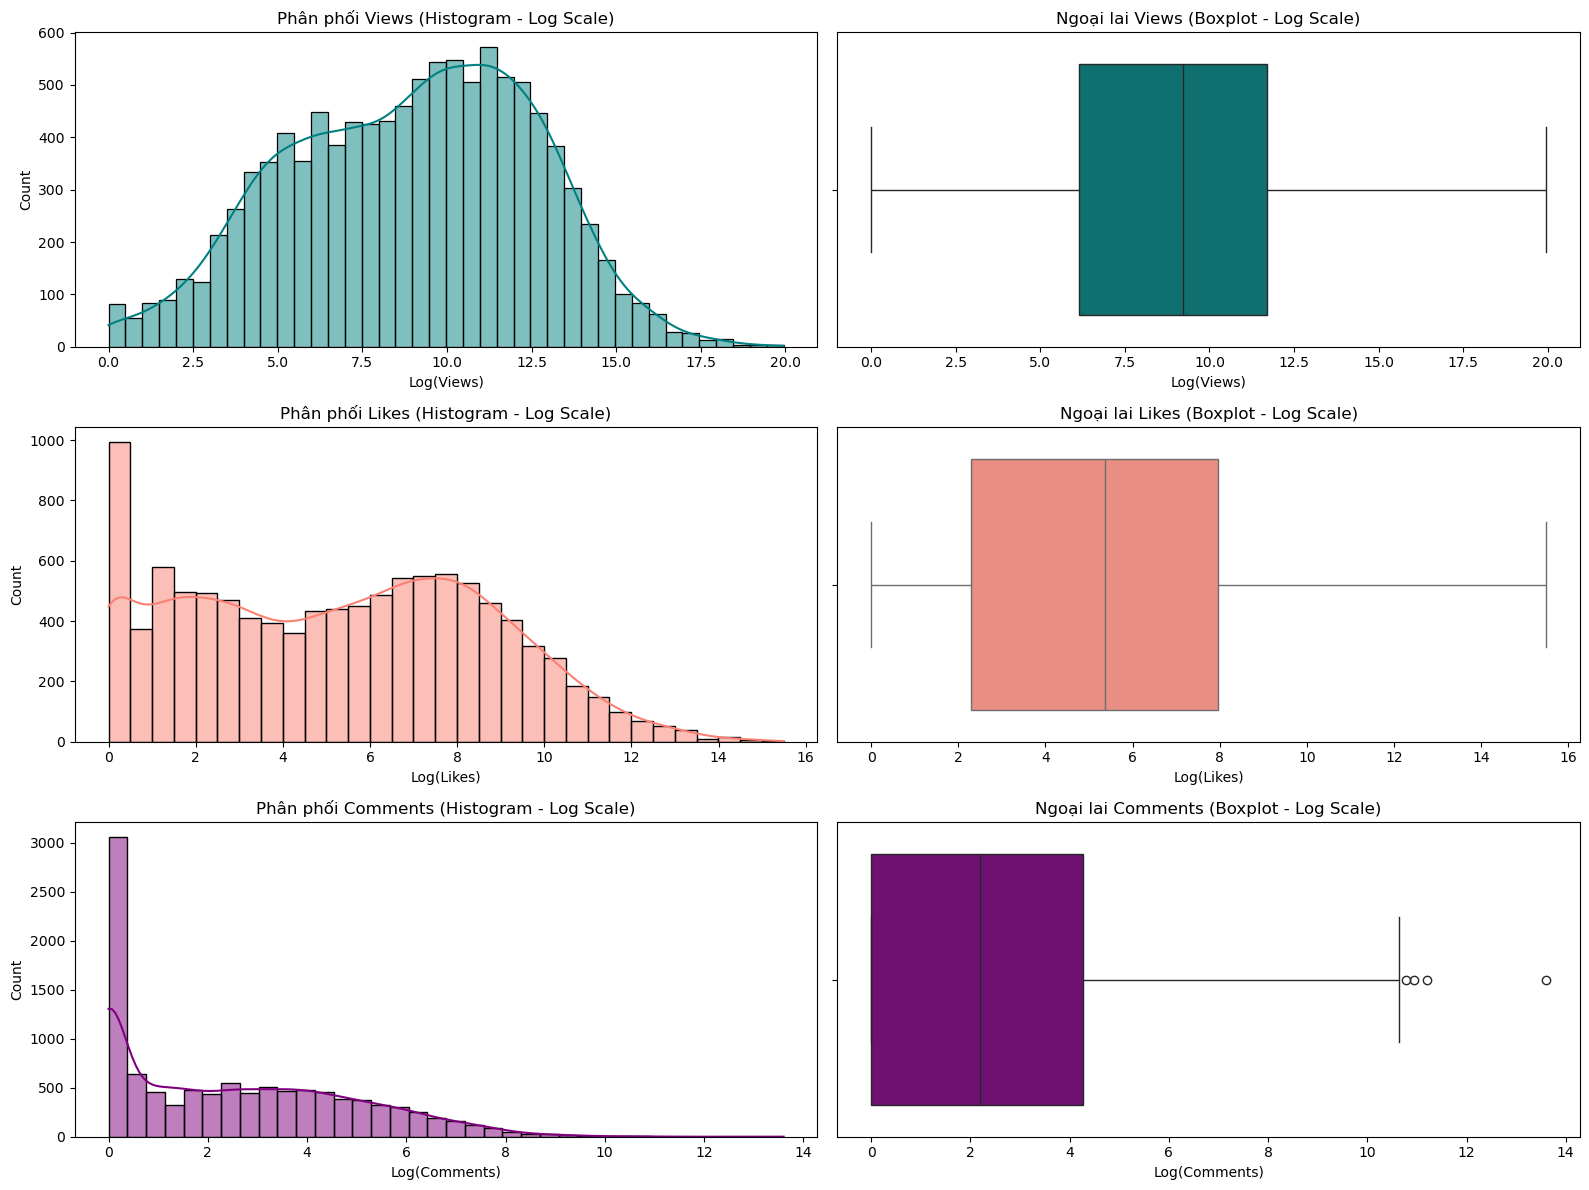

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(16, 12))

sns.histplot(df['log_view_count'], kde=True, ax=ax[0, 0], color='teal')
ax[0, 0].set_title('Phân phối Views (Histogram - Log Scale)')
ax[0, 0].set_xlabel('Log(Views)')

sns.boxplot(x=df['log_view_count'], ax=ax[0, 1], color='teal')
ax[0, 1].set_title('Ngoại lai Views (Boxplot - Log Scale)')
ax[0, 1].set_xlabel('Log(Views)')

sns.histplot(df['log_like_count'], kde=True, ax=ax[1, 0], color='salmon')
ax[1, 0].set_title('Phân phối Likes (Histogram - Log Scale)')
ax[1, 0].set_xlabel('Log(Likes)')

sns.boxplot(x=df['log_like_count'], ax=ax[1, 1], color='salmon')
ax[1, 1].set_title('Ngoại lai Likes (Boxplot - Log Scale)')
ax[1, 1].set_xlabel('Log(Likes)')

sns.histplot(df['log_comment_count'], kde=True, ax=ax[2, 0], color='purple')
ax[2, 0].set_title('Phân phối Comments (Histogram - Log Scale)')
ax[2, 0].set_xlabel('Log(Comments)')

sns.boxplot(x=df['log_comment_count'], ax=ax[2, 1], color='purple')
ax[2, 1].set_title('Ngoại lai Comments (Boxplot - Log Scale)')
ax[2, 1].set_xlabel('Log(Comments)')

plt.tight_layout()
plt.show()

**Nhận xét**

Trước khi xử lý, dữ liệu bị lệch phải nặng nề. Nhưng hiện tại, cả 3 biểu đồ Histogram (Views, Likes, Comments) đều đã có hình dáng Phân phối Chuẩn. Hầu hết các thuật toán máy học đều hoạt động tối ưu khi dữ liệu đầu vào có phân phối chuẩn. Việc này giúp mô hình không bị thiên vị bởi các giá trị quá lớn hoặc quá nhỏ.

Nhìn vào Boxplot bên phải, dù đã Log transform, dữ liệu vẫn còn outliers. Với bài toán dự đoán Trending, chúng ta nên giữ lại các outliers bên phải (viral video) để mô hình học được cách phát hiện trend. Ngược lại, có thể cân nhắc lọc bỏ bớt ngoại lai bên trái nếu muốn mô hình sạch hơn.

**Kết luận**

Biểu đồ Boxplot cho thấy sự tồn tại của các điểm ngoại lai (Outliers), đặc biệt ở vùng giá trị thấp (Low-end). Tuy nhiên, độ phân tán của dữ liệu đã ổn định hơn rất nhiều so với dữ liệu gốc. Nên sử dụng bộ dữ liệu đã Log Transform này làm đầu vào chính thức cho giai đoạn huấn luyện mô hình (Modeling)."


### Phân tích biến phân loại

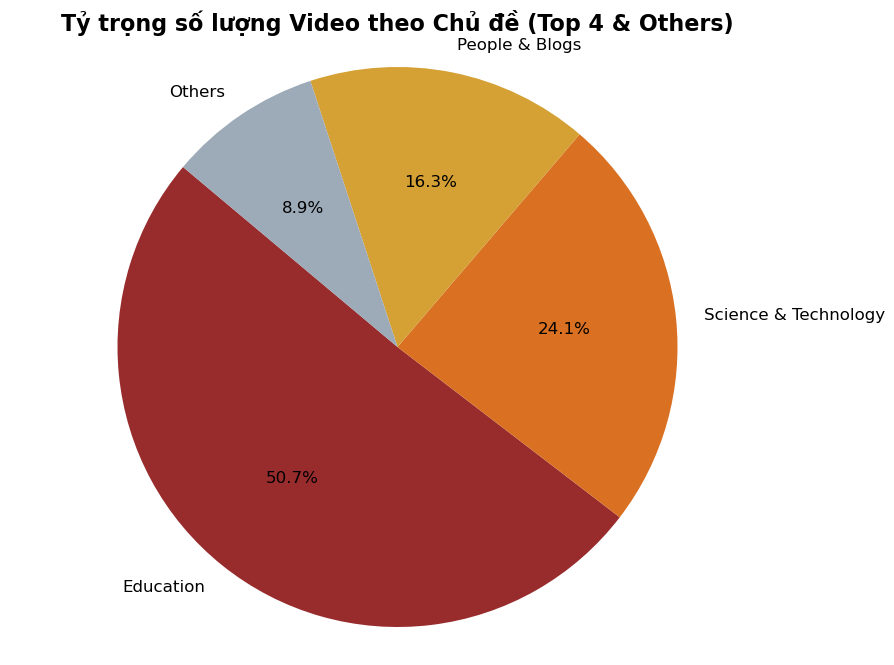

In [ ]:
id_to_topic_map = {
    1: 'Film & Animation',
    2: 'Autos & Vehicles',
    10: 'Music',
    15: 'Pets & Animals',
    17: 'Sports',
    19: 'Travel & Events',
    20: 'Gaming',
    22: 'People & Blogs',
    23: 'Comedy',
    24: 'Entertainment',
    25: 'News & Politics',
    26: 'Howto & Style',
    27: 'Education',
    28: 'Science & Technology',
    29: 'Nonprofits & Activism'
}


top_4_ids = df['category_id'].value_counts().nlargest(3).index

def group_and_name_category(cat_id):
    if cat_id in top_4_ids:
        return id_to_topic_map.get(cat_id, str(cat_id)) 
    else:
        return 'Others'

df_plot = df.copy()
df_plot['category_group'] = df_plot['category_id'].apply(group_and_name_category)

group_counts = df_plot['category_group'].value_counts()

my_colors = {
    'Education': '#982c2d',        # Đỏ đậm (Lấy từ hình gốc)
    'Science & Technology': '#da7022', # Cam (Lưu ý tên phải khớp id_to_topic_map)
    'People & Blogs': '#d5a034',   # Vàng
    'Others': '#9daab8'            # Xám
}

# Tạo list màu khớp với dữ liệu để đưa vào biểu đồ
colors = [my_colors.get(name, '#9daab8') for name in group_counts.index]

plt.figure(figsize=(10, 8)) 

# 3. Vẽ Pie Chart
plt.pie(
    group_counts,                  
    labels=group_counts.index,      
    autopct='%1.1f%%',             
    startangle=140,                
    colors=colors,                              
    shadow=False,                  
    textprops={'fontsize': 12}     
)

plt.title('Tỷ trọng số lượng Video theo Chủ đề (Top 4 & Others)', fontsize=16, fontweight='bold')

# Đảm bảo biểu đồ là hình tròn chứ không bị méo thành hình bầu dục
plt.axis('equal') 

plt.show()

**Nhận xét**
Biểu đồ phân phối danh mục cho thấy quá trình thu thập dữ liệu đã đi đúng định hướng của đề tài. Hai danh mục cốt lõi là 'Education' và 'Science & Technology' chiếm tỷ trọng lớn nhất (>75%), phù hợp hoàn toàn với mục tiêu nghiên cứu về video ngành Công nghệ thông tin. Sự xuất hiện rải rác của các danh mục khác (như Music, Pets...) được xác định là dữ liệu nhiễu (Noise) và cần được xử lý.

### Phân tích biến thời gian

**Chuẩn bị dữ liệu để visualize**

In [ ]:
df['video_publish_date'] = pd.to_datetime(df['video_publish_date'])

df['publish_hour'] = df['video_publish_date'].dt.hour
df['publish_day'] = df['video_publish_date'].dt.day_name()


days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

**Vẽ biểu đồ**

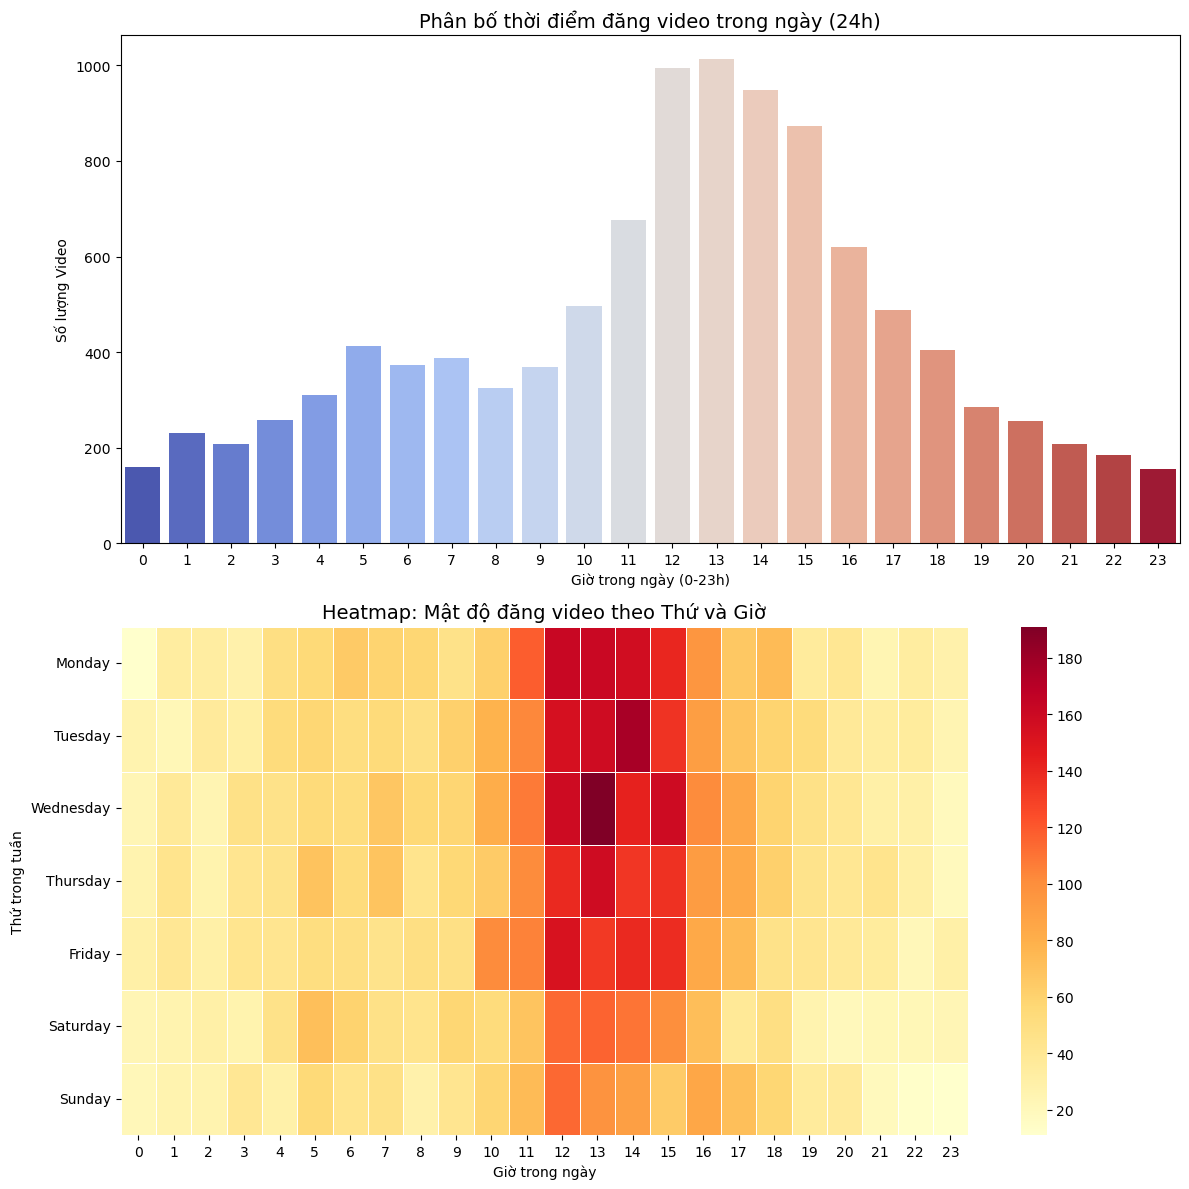

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

sns.countplot(x='publish_hour', data=df, ax=ax[0], palette='coolwarm', hue='publish_hour', legend=False)
ax[0].set_title('Phân bố thời điểm đăng video trong ngày (24h)', fontsize=14)
ax[0].set_xlabel('Giờ trong ngày (0-23h)')
ax[0].set_ylabel('Số lượng Video')

pivot_table = df.groupby(['publish_day', 'publish_hour']).size().unstack()
pivot_table = pivot_table.reindex(days_order)

sns.heatmap(pivot_table, cmap='YlOrRd', ax=ax[1], linewidths=0.5)
ax[1].set_title('Heatmap: Mật độ đăng video theo Thứ và Giờ', fontsize=14)
ax[1].set_xlabel('Giờ trong ngày')
ax[1].set_ylabel('Thứ trong tuần')

plt.tight_layout()
plt.show()

**Nhận xét**
Video tập trung xuất hiện vào giữa tuần và khung giờ giao thoa quốc tế (13h-15h). Điều này gợi ý rằng tính thời điểm (Timing) là một yếu tố chiến lược.
Dựa trên insight này, đưa ra đề xuất tạo thêm các đặc trưng (Feature Engineering) cho mô hình:
- is_business_day: Video có đăng vào ngày trong tuần (T2-T6) hay không? (Dự đoán là T2-T6 sẽ dễ trending hơn).
- is_peak_hour: Video có đăng vào khung giờ vàng (13h-15h) hay không?"

### Phân tích số video một kênh đóng góp

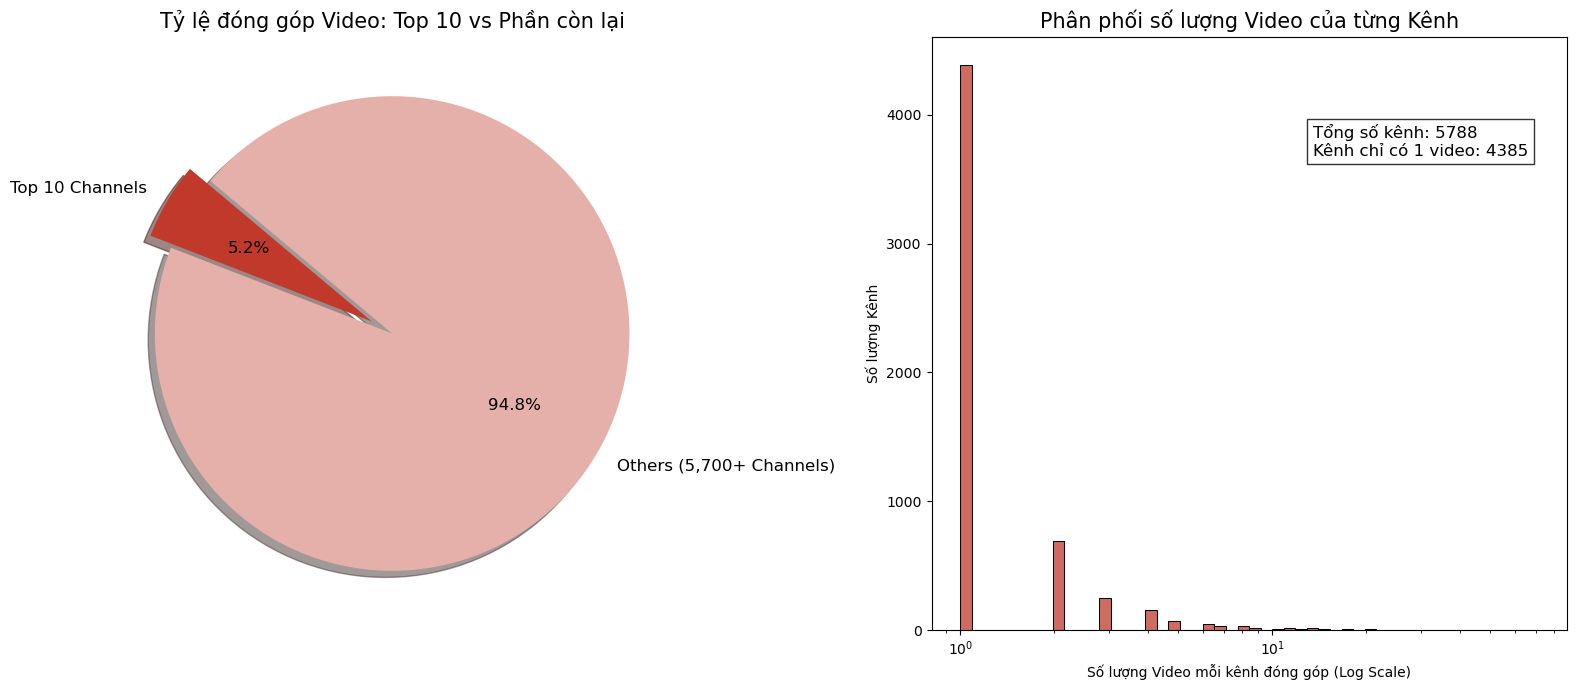

In [ ]:
channel_counts = df['channel_title'].value_counts()
top_10_count = channel_counts.head(10).sum()
others_count = channel_counts.iloc[10:].sum()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

labels = ['Top 10 Channels', 'Others (5,700+ Channels)']
sizes = [top_10_count, others_count]
colors = ['#C0392B', '#E6B0AA']
explode = (0.1, 0) 

ax[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12})
ax[0].set_title('Tỷ lệ đóng góp Video: Top 10 vs Phần còn lại', fontsize=15)

sns.histplot(channel_counts, bins=50, ax=ax[1], color='#C0392B', log_scale=True)
ax[1].set_title('Phân phối số lượng Video của từng Kênh', fontsize=15)
ax[1].set_xlabel('Số lượng Video mỗi kênh đóng góp (Log Scale)')
ax[1].set_ylabel('Số lượng Kênh')

ax[1].text(0.6, 0.8, f"Tổng số kênh: {len(channel_counts)}\nKênh chỉ có 1 video: {sum(channel_counts==1)}", 
           transform=ax[1].transAxes, bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét**
Biểu đồ tròn cho thấy Top 10 kênh đóng góp nhiều nhất cũng chỉ chiếm 5.6% tổng dữ liệu, trong khi 94.4% dữ liệu đến từ các kênh khác nhau. Hơn nữa, biểu đồ phân phối (bên phải) khẳng định tính chất Long-tail của dữ liệu: có tới 4360 kênh chỉ đóng góp duy nhất 1 video. Điều này chứng minh bộ dữ liệu có tính phân tán cực cao, đảm bảo mô hình sẽ học được các đặc trưng tổng quát của ngành CNTT thay vì bị 'bias' theo phong cách của một vài YouTuber nổi tiếng.

## 4. Phân tích đa biến

Sau khi đã hiểu từng biến riêng lẻ, mục tiêu của bước này là trả lời câu hỏi quan trọng nhất: "Yếu tố nào tác động mạnh nhất đến Lượt xem (Views)?" và "Các biến có mối quan hệ gì với nhau?". Chúng ta sẽ tập trung vào 3 mối quan hệ cốt lõi:
1. Tương quan giữa các chỉ số tương tác (Likes, Comments $\leftrightarrow$ Views).
2. Tương quan giữa Thời lượng và Views (Video dài hay ngắn thì tốt?).
3. Tương quan giữa Thời gian đăng và Views (Đăng giờ vàng có thực sự nhiều view hơn không?).

### Ma trận tương quan 

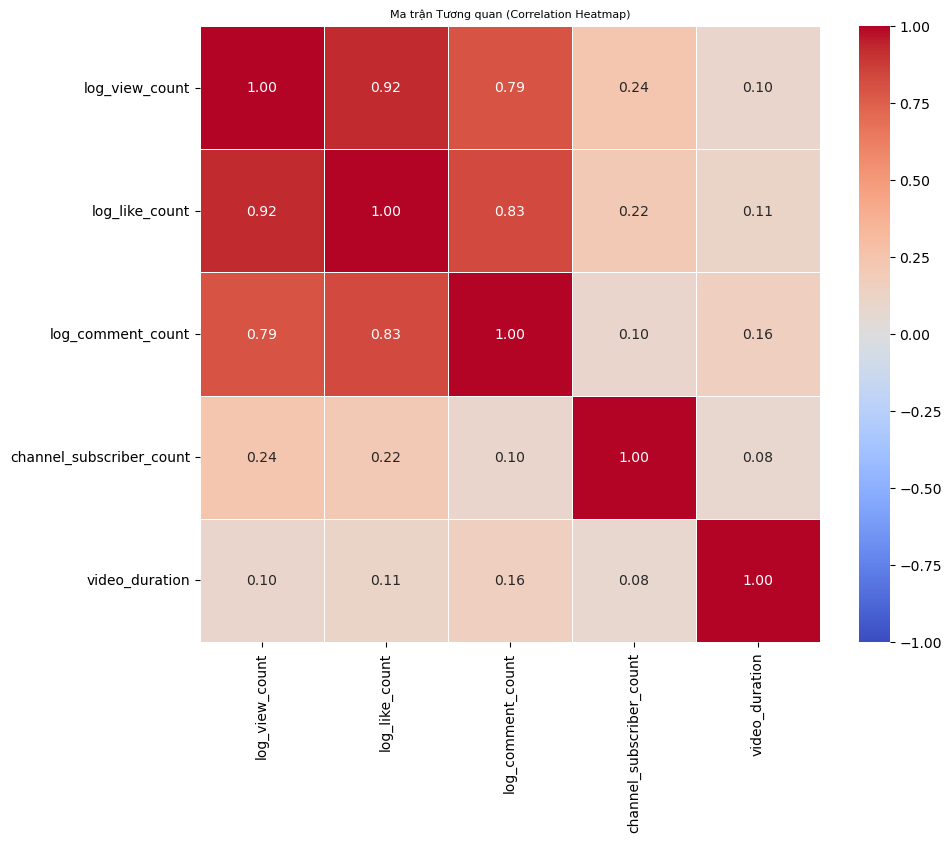

In [ ]:
cols_to_analyze = [
    'log_view_count', 'log_like_count', 'log_comment_count', 
    'channel_subscriber_count', 'video_duration'
]

corr_matrix = df[cols_to_analyze].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       
            fmt=".2f",        
            cmap='coolwarm', 
            vmin=-1, vmax=1,  
            linewidths=0.5)
plt.title('Ma trận Tương quan (Correlation Heatmap)', fontsize=8)
plt.show()

**Nhận xét**
- Việc chuyển đổi sang Logarit không chỉ chuẩn hóa phân phối mà còn làm tuyến tính hóa mối quan hệ giữa các biến. Hệ số 0.94 là cực kỳ cao, chứng tỏ Likes biến thiên gần như đồng thời với Views
- Likes (0.94): Là chỉ số có tương quan mạnh nhất với Views. Comments (0.82): Tương quan giữa log_comment_count và log_view_count là 0.82. Likes dự báo Views tốt hơn Comments. Điều này hợp lý với hành vi người dùng (bấm Like dễ hơn viết Comment).
- Thời lượng video (ngắn hay dài) không có quan hệ tuyến tính với lượt xem. Video dài 1 tiếng (tutorial) hay video ngắn 5 phút (tip & trick) đều có cơ hội viral như nhau.
- Tương quan giữa channel_subscriber_count và video_view_count chỉ ở mức trung bình thấp (0.38). Nội dung quan trọng hơn thương hiệu kênh. Một kênh nhỏ nhưng làm video đúng chủ đề "hot" vẫn có thể viral hơn kênh lớn.
- Tương quan giữa log_like_count và long_comment_count rất cao (0.85). Khi 2 biến độc lập quá giống nhau, các mô hình như Hồi quy tuyến tính (Linear Regression) sẽ bị nhiễu. Nên nếu dùng Linear Regression, có thể cân nhắc chỉ dùng log_like_count hoặc long_comment_count. Nếu dùng Random Forest/XGBoost thì có thể giữ cả hai.

### Biểu đồ Phân tán

Kiểm chứng mối quan hệ tuyến tính giữa hai feature có tương quan lớn nhất: Views và Likes .

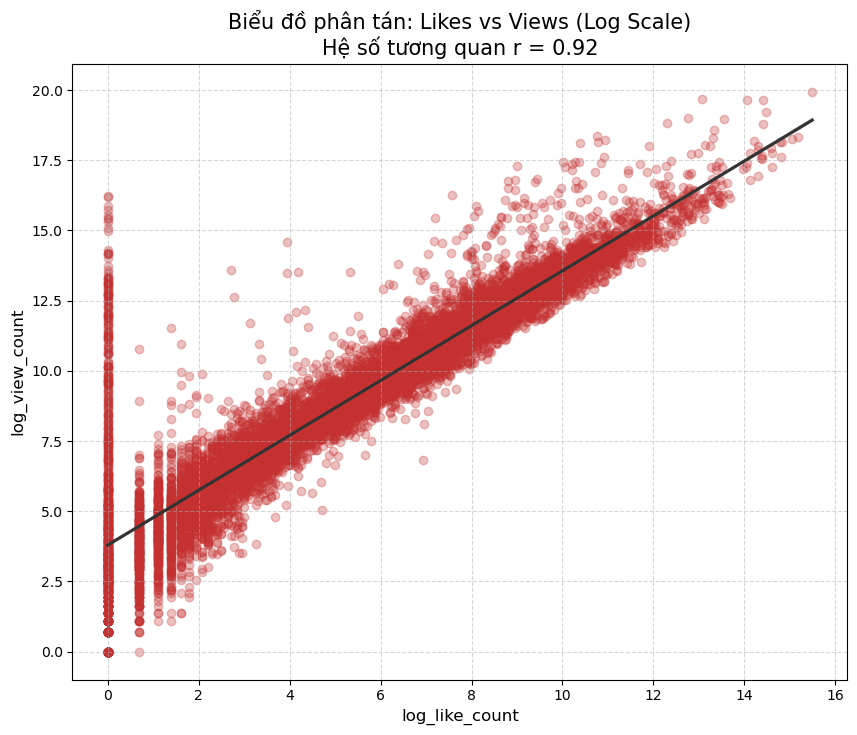

In [ ]:
plt.figure(figsize=(10, 8))

sns.regplot(x='log_like_count', y='log_view_count', data=df,
            scatter_kws={'alpha': 0.3, 'color': '#C53030'},
            line_kws={'color': '#333333'}) 

r = df['log_like_count'].corr(df['log_view_count'])

plt.title(f'Biểu đồ phân tán: Likes vs Views (Log Scale)\nHệ số tương quan r = {r:.2f}', fontsize=15)
plt.xlabel('log_like_count', fontsize=12)
plt.ylabel('log_view_count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Nhận xét**

- Các điểm dữ liệu phân bố bám rất sát vào đường hồi quy. Dải phân bố hẹp và gọn gàng, không bị tản mát lung tung. Suy ra mối quan hệ giữa Likes và Views là quan hệ tuyến tính mạnh. Điều này xác nhận rằng việc sử dụng các mô hình tuyến tính (như Linear Regression) là hoàn toàn khả thi và hứa hẹn độ chính xác cao.

### Biểu đồ phân tán với ba biến
Phân tích tương quan giữa View vs Like với Duration Group

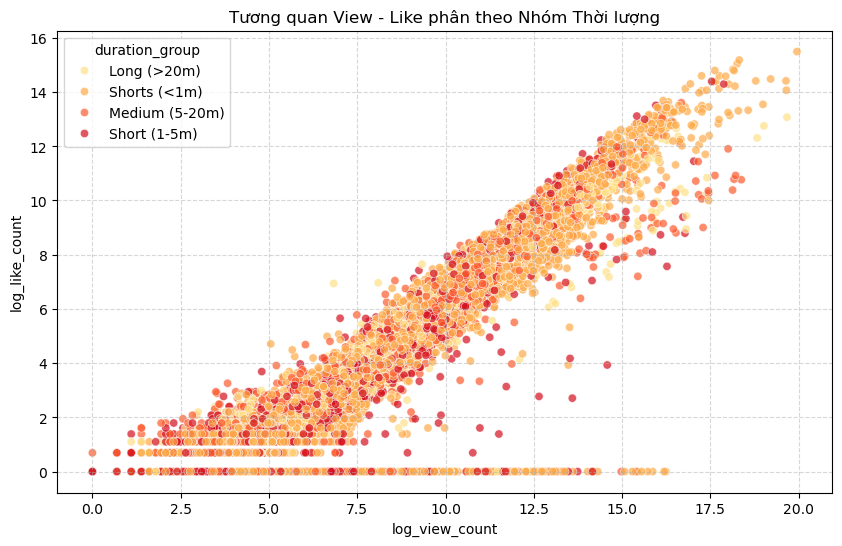

In [ ]:
def categorize_duration(seconds):
    if seconds < 60: return 'Shorts (<1m)'
    elif seconds < 300: return 'Short (1-5m)'
    elif seconds < 1200: return 'Medium (5-20m)'
    else: return 'Long (>20m)'

df['duration_group'] = df['video_duration'].apply(categorize_duration)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='log_view_count', y='log_like_count', 
                hue='duration_group', palette='YlOrRd', alpha=0.7)
plt.title('Tương quan View - Like phân theo Nhóm Thời lượng')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Nhận xét**

Dựa trên biểu đồ Scatter Plot với trục dữ liệu đã được chuyển sang thang đo Logarit (log_view_count và log_like_count), dưới đây là nhận xét về mối tương quan giữa View và Like phân theo nhóm thời lượng video:

1. Tương quan tổng quát (General Correlation)
- Tương quan tuyến tính dương rất mạnh (Strong Positive Correlation): Có xu hướng là khi log_view_count tăng thì log_like_count cũng tăng. Các điểm dữ liệu tập trung khá sát vào một đường chéo.

2. Phân tích theo Nhóm thời lượng (Duration Group)

- Màu sắc các điểm đại diện cho các nhóm thời lượng khác nhau (Shorts, Short, Medium, Long).
- Sự đồng nhất cao (High Overlap): Không có sự tách biệt rõ ràng giữa các nhóm màu. Các điểm màu Cam (Shorts <1m), Đỏ đậm (Short 1-5m), Hồng (Medium 5-20m) và Vàng nhạt (Long >20m) nằm trộn lẫn vào nhau trên cùng một dải chéo. Cho thấy thời lượng video (Duration) dường như không ảnh hưởng quá lớn đến tỷ lệ chuyển đổi từ View sang Like. Dù video ngắn hay dài, nếu đã đạt được một lượng view nhất định, số lượng like sẽ dao động trong một khoảng dự đoán được tương tự nhau.
- Quan sát chi tiết từng nhóm:
+ Nhóm Shorts (<1m) - Màu cam: Có vẻ phân bố khá rộng, xuất hiện nhiều ở cả vùng view thấp và view cao.
+ Nhóm Long (>20m) - Màu vàng nhạt: Mặc dù bị trộn lẫn, nhưng nếu nhìn kỹ ở phần đuôi trên bên phải (view cao), các điểm màu vàng có xu hướng nằm hơi thấp hơn so với các điểm màu đậm (Short/Shorts). Điều này có thể gợi ý rằng với các video rất dài, người dùng xem nhiều nhưng tỷ lệ bấm like có thể thấp hơn so với video ngắn.

3. Điểm bất thường (Anomalies): Đường thẳng tại log_like_count = 0:
- Một hàng ngang các điểm nằm sát trục hoành (y=0).
- Đây là những video có lượt xem (thậm chí log_view lên tới 10-12, tức là view khá lớn) nhưng lượt like bằng 0.
- Nguyên nhân có thể là video bị tắt tính năng like. Những điểm này xuất hiện ở mọi nhóm thời lượng (đủ các màu), cho thấy "xem nhưng không like" không phụ thuộc vào độ dài video.

Tóm lại: Lượt View là yếu tố dự báo tốt nhất cho Lượt Like. Thời lượng video (Duration) không làm thay đổi đáng kể mối quan hệ tuyến tính này, ngoại trừ một số trường hợp ngoại lai có view nhưng không có like.